# Raport: Metody Systemowe i Decyzyjne – Lista III

**Autor:** Michał Śliwa

### Charakterystyka cech (Heart Disease – Cleveland):

| Cecha | Typ | Opis |
|-------|-----|------|
| `age` | Liczbowa ciągła | Wiek pacjenta (lata) |
| `trestbps` | Liczbowa ciągła | Spoczynkowe ciśnienie krwi (mm Hg) |
| `chol` | Liczbowa ciągła | Cholesterol w surowicy (mg/dl) |
| `thalach` | Liczbowa ciągła | Maksymalne osiągnięte tętno |
| `oldpeak` | Liczbowa ciągła | Obniżenie odcinka ST wywołane wysiłkiem |
| `sex` | Kategorialna | Płeć (1 = mężczyzna, 0 = kobieta) |
| `cp` | Kategorialna | Rodzaj bólu w klatce piersiowej (1–4) |
| `fbs` | Kategorialna | Cukier na czczo > 120 mg/dl (1 = tak) |
| `restecg` | Kategorialna | Wynik EKG w spoczynku (0–2) |
| `exang` | Kategorialna | Dławica wywołana wysiłkiem (1 = tak) |
| `slope` | Kategorialna | Nachylenie odcinka ST (1–3) |
| `ca` | Kategorialna | Liczba głównych naczyń wieńcowych (0–3) |
| `thal` | Kategorialna | Wynik testu talu (3, 6, 7) |
| `target` | Zmienna docelowa | Diagnoza: 0 = zdrowy, 1 = chory |


# 1. Przygotowanie danych

Wczytuję dataset Heart Disease (Cleveland) – ten sam co na Liście 2. Dzielę dane na zbiór treningowy i testowy w proporcji 4:1 z tym samym `random_state=42`, aby wyniki były porównywalne z poprzednią listą.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             mean_squared_error, mean_absolute_error)
from IPython.display import display

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv('../lista2/data/processed.cleveland.data',
                 header=None, names=columns, na_values='?')
df = df.dropna()
df['target_bin'] = (df['target'] > 0).astype(int)

X_cls = df.drop(['target', 'target_bin'], axis=1)
y_cls = df['target_bin']
X_reg = df.drop(['target', 'target_bin', 'thalach'], axis=1)
y_reg = df['thalach']

X_train, X_test, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler_cls = StandardScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_test_sc = scaler_cls.transform(X_test)

scaler_reg = StandardScaler()
X_train_reg_sc = scaler_reg.fit_transform(X_train_reg)
X_test_reg_sc = scaler_reg.transform(X_test_reg)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego:    {X_test.shape}")
print(f"Rozkład klas: {y_cls.value_counts().to_dict()}")

results_summary = {}


Rozmiar zbioru treningowego: (237, 13)
Rozmiar zbioru testowego:    (60, 13)
Rozkład klas: {0: 160, 1: 137}


# 2. Regularyzacja (ocena 3.0)

Regularyzacja to technika nakładania matematycznego „kagańca" na model, aby zapobiec przeuczeniu. Dodajemy do funkcji kosztu dodatkowy człon kary za duże wagi:

- **Ridge (L2):** kara to suma kwadratów wag → wagi są „ściągane" w kierunku zera, ale nigdy nie wyzerowane
- **Lasso (L1):** kara to suma wartości bezwzględnych wag → część wag może zostać dokładnie wyzerowana (automatyczna selekcja cech)


## 2.1 Własna implementacja Regresji z karą L1 i L2

Rozszerzam klasę `MyLinearRegression` z Listy 2 o regularyzację Lasso i Ridge w metodzie Gradient Descent. Gradient dla Ridge i Lasso różni się tylko sposobem obliczania pochodnej członu kary.


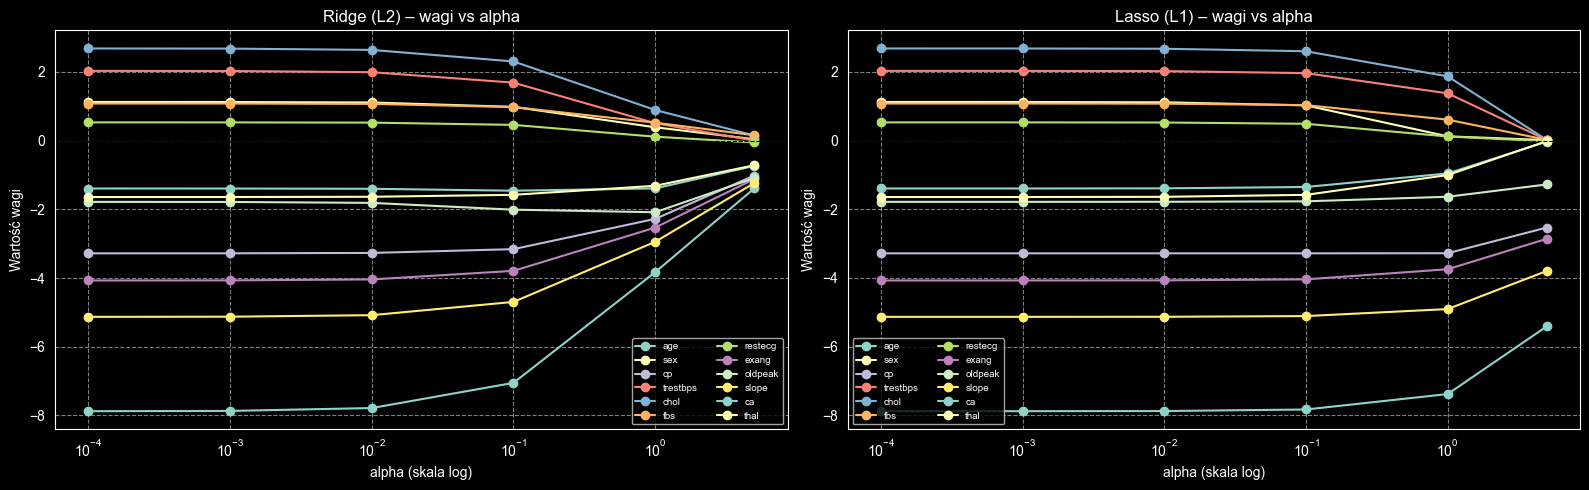

In [12]:
class MyRegularizedRegression:
    def __init__(self, mode='ridge', alpha=1.0):
        self.mode = mode
        self.alpha = alpha
        self.weights = None

    def fit(self, X, y, lr=0.01, epochs=2000):
        n, p = X.shape
        X_b = np.c_[np.ones(n), X]
        self.weights = np.zeros(X_b.shape[1])

        for _ in range(epochs):
            residual = X_b @ self.weights - y
            grad = (2 / n) * X_b.T @ residual

            penalty = 2 * self.alpha * self.weights if self.mode == 'ridge' else self.alpha * np.sign(self.weights)
            penalty[0] = 0.0
            self.weights -= lr * (grad + penalty)

    def predict(self, X):
        X_b = np.c_[np.ones(len(X)), X]
        return X_b @ self.weights


alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0]
feat_names = list(X_train_reg.columns)

ridge_weights, lasso_weights = [], []
for alpha in alphas:
    r = MyRegularizedRegression(mode='ridge', alpha=alpha)
    r.fit(X_train_reg_sc, y_train_reg.values)
    ridge_weights.append(r.weights[1:].copy())

    l = MyRegularizedRegression(mode='lasso', alpha=alpha)
    l.fit(X_train_reg_sc, y_train_reg.values, lr=0.005, epochs=3000)
    lasso_weights.append(l.weights[1:].copy())

ridge_weights = np.array(ridge_weights)
lasso_weights = np.array(lasso_weights)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for j, name in enumerate(feat_names):
    axes[0].plot(alphas, ridge_weights[:, j], marker='o', label=name)
    axes[1].plot(alphas, lasso_weights[:, j], marker='o', label=name)
for ax, title in zip(axes, ['Ridge (L2) – wagi vs alpha', 'Lasso (L1) – wagi vs alpha']):
    ax.set_xscale('log')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('alpha (skala log)'); ax.set_ylabel('Wartość wagi')
    ax.set_title(title); ax.legend(fontsize=7, ncol=2); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('regularization_weights.png', dpi=100, bbox_inches='tight')
plt.show()


**Wniosek z wykresu:** Ridge (L2) „ściska" wagi ku zeru, ale ich nie zeruje — wszystkie linie pozostają niezerowe nawet dla dużych `alpha`. Lasso (L1) faktycznie zeruje wagi słabszych cech — linie na wykresie schodzą i leżą dokładnie na poziomie 0, co czyni Lasso automatycznym selektorem cech.


## 2.2 Porównanie błędów testowych dla różnych alpha


In [13]:
rows = []
for alpha in alphas:
    r = MyRegularizedRegression(mode='ridge', alpha=alpha)
    r.fit(X_train_reg_sc, y_train_reg.values)
    y_r = r.predict(X_test_reg_sc)

    l = MyRegularizedRegression(mode='lasso', alpha=alpha)
    l.fit(X_train_reg_sc, y_train_reg.values, lr=0.005, epochs=3000)
    y_l = l.predict(X_test_reg_sc)

    rows.append({
        'alpha': alpha,
        'Ridge MSE': mean_squared_error(y_test_reg, y_r),
        'Ridge MAE': mean_absolute_error(y_test_reg, y_r),
        'Lasso MSE': mean_squared_error(y_test_reg, y_l),
        'Lasso MAE': mean_absolute_error(y_test_reg, y_l),
        'Lasso wagi≈0': np.sum(np.abs(l.weights[1:]) < 0.01),
    })

df_reg_table = pd.DataFrame(rows)
display(df_reg_table.round(2))

best_ridge_alpha = df_reg_table.loc[df_reg_table['Ridge MSE'].idxmin(), 'alpha']
best_lasso_alpha = df_reg_table.loc[df_reg_table['Lasso MSE'].idxmin(), 'alpha']
print(f"Najlepsze Ridge: alpha={best_ridge_alpha}")
print(f"Najlepsze Lasso: alpha={best_lasso_alpha}")


,alpha,Ridge MSE,Ridge MAE,Lasso MSE,Lasso MAE,Lasso wagi≈0
0,0.00,298.08,14.25,298.08,14.25,0
1,0.00,298.05,14.25,298.07,14.25,0
2,0.01,297.70,14.25,297.91,14.25,0
3,0.10,295.38,14.23,296.31,14.22,0
4,1.00,306.85,14.85,283.16,14.06,0
5,5.00,376.00,16.56,296.27,14.76,0


Najlepsze Ridge: alpha=0.1
Najlepsze Lasso: alpha=1.0


## 2.3 Regularyzacja drzew decyzyjnych

Na Liście 2 kontrolowałem złożoność drzewa parametrem `max_depth`. Teraz badam dodatkowe parametry strukturalne:

- **`min_samples_split`** – minimalna liczba próbek w węźle potrzebna do jego podziału
- **`min_samples_leaf`** – minimalna liczba próbek w liściu
- **`max_features`** – ułamek cech losowanych przy każdym podziale


Bazowe drzewo – Accuracy: 0.783  F1: 0.755  Głębokość: 10


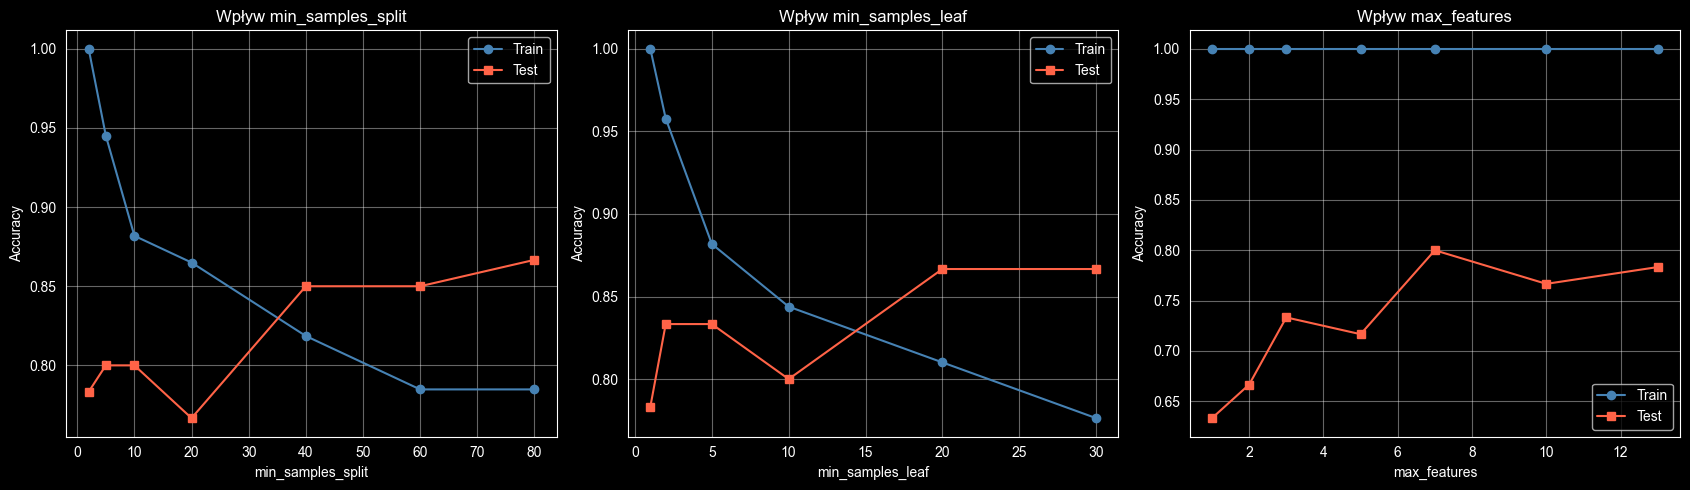

Zregularyzowane drzewo (min_samples_split=80, min_samples_leaf=5)
Accuracy: 0.867  F1: 0.833  | Poprawa vs bazowe: +0.083


In [14]:
from sklearn.tree import DecisionTreeClassifier

tree_base = DecisionTreeClassifier(random_state=42)
tree_base.fit(X_train, y_train_cls)
y_base_pred = tree_base.predict(X_test)
acc_base = accuracy_score(y_test_cls, y_base_pred)
_, _, f1_base, _ = precision_recall_fscore_support(y_test_cls, y_base_pred, average='binary')
results_summary['Drzewo bazowe'] = {'Accuracy': acc_base, 'F1': f1_base}
print(f"Bazowe drzewo – Accuracy: {acc_base:.3f}  F1: {f1_base:.3f}  Głębokość: {tree_base.get_depth()}")

mss_range = [2, 5, 10, 20, 40, 60, 80]
msl_range = [1, 2, 5, 10, 20, 30]
mf_range = [1, 2, 3, 5, 7, 10, 13]

def sweep(param, values):
    train_accs, test_accs = [], []
    for v in values:
        t = DecisionTreeClassifier(**{param: v}, random_state=42)
        t.fit(X_train, y_train_cls)
        train_accs.append(accuracy_score(y_train_cls, t.predict(X_train)))
        test_accs.append(accuracy_score(y_test_cls,  t.predict(X_test)))
    return train_accs, test_accs

mss_tr, mss_te = sweep('min_samples_split', mss_range)
msl_tr, msl_te = sweep('min_samples_leaf', msl_range)
mf_tr, mf_te = sweep('max_features', mf_range)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, vals, tr, te, lbl in zip(
        axes,
        [mss_range, msl_range, mf_range],
        [mss_tr, msl_tr, mf_tr],
        [mss_te, msl_te, mf_te],
        ['min_samples_split', 'min_samples_leaf', 'max_features']):
    ax.plot(vals, tr, 'o-', label='Train', color='steelblue')
    ax.plot(vals, te, 's-', label='Test',  color='tomato')
    ax.set_xlabel(lbl); ax.set_ylabel('Accuracy')
    ax.set_title(f'Wpływ {lbl}')
    ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('tree_regularization.png', dpi=100, bbox_inches='tight')
plt.show()

best_mss = mss_range[int(np.argmax(mss_te))]
tree_reg = DecisionTreeClassifier(min_samples_split=best_mss, min_samples_leaf=5, random_state=42)
tree_reg.fit(X_train, y_train_cls)
y_tree_reg_pred = tree_reg.predict(X_test)
acc_tr = accuracy_score(y_test_cls, y_tree_reg_pred)
_, _, f1_tr, _ = precision_recall_fscore_support(y_test_cls, y_tree_reg_pred, average='binary')
results_summary['Drzewo zregularyzowane'] = {'Accuracy': acc_tr, 'F1': f1_tr}
print(f"Zregularyzowane drzewo (min_samples_split={best_mss}, min_samples_leaf=5)")
print(f"Accuracy: {acc_tr:.3f}  F1: {f1_tr:.3f}  | Poprawa vs bazowe: {acc_tr - acc_base:+.3f}")


**Wniosek z wykresów:** Bazowe drzewo (bez ograniczeń) osiąga Accuracy ≈ 1.0 na treningu, ale słabsze wyniki na teście — klasyczny overfitting. Zwiększenie `min_samples_split` i `min_samples_leaf` redukuje głębokość drzewa i poprawia generalizację. Parametr `max_features` działa jak regularyzacja stochastyczna — losowanie podzbioru cech przy każdym podziale zwiększa różnorodność modelu.


## 2.4 Analiza: Lasso vs Ridge – wpływ na współczynniki

**Lasso (L1)** nakłada karę proporcjonalną do |w|. Geometrycznie „diamentowy" obszar dopuszczalny ma ostre narożniki leżące na osiach — optymalny punkt bardzo często wypada w takim narożniku, co powoduje wyzerowanie części wag. **Lasso pełni więc rolę selektora cech.**

**Ridge (L2)** nakłada karę proporcjonalną do w². Obszar dopuszczalny to kula — brak ostrych krawędzi. Ridge **ściąga** wagi ku zeru, ale ich nie zeruje.

**Efekt na błąd testowy:** Regularyzacja redukuje wariancję modelu (zmniejsza overfitting). Zbyt duże `alpha` powoduje underfitting — dlatego kluczowy jest dobór tego hiperparametru.


# 3. Bagging – Bootstrap Aggregating (ocena 3.5)

Bagging to technika łączenia wielu identycznych modeli trenowanych na różnych podzbiorach danych (losowanie **ze zwracaniem**). Redukuje **wariancję** modelu bez zwiększania biasu.


## 3.1 scikit-learn: RandomForestClassifier vs pojedyncze drzewo


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_cls)
y_rf_pred = rf.predict(X_test)

acc_rf = accuracy_score(y_test_cls, y_rf_pred)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test_cls, y_rf_pred, average='binary')
results_summary['Random Forest (sklearn)'] = {'Accuracy': acc_rf, 'F1': f1_rf}

_, pr_b, rc_b, _ = precision_recall_fscore_support(y_test_cls, y_base_pred, average='binary')
comp = pd.DataFrame({
    'Model':     ['Pojedyncze drzewo (bazowe)', 'Random Forest (100 drzew)'],
    'Accuracy':  [acc_base, acc_rf],
    'F1 Score':  [f1_base, f1_rf],
    'Precision': [pr_b, prec_rf],
    'Recall':    [rc_b, rec_rf],
})
display(comp.round(3))
print(f"Random Forest poprawia accuracy o {acc_rf - acc_base:+.3f} vs pojedyncze drzewo")


,Model,Accuracy,F1 Score,Precision,Recall
0,Pojedyncze drzewo (bazowe),0.783,0.755,0.833,0.755
1,Random Forest (100 drzew),0.883,0.857,0.840,0.875


Random Forest poprawia accuracy o +0.100 vs pojedyncze drzewo


## 3.2 Własna implementacja Baggingu

Implementuję klasę `MyBagging` od zera:
1. **Bootstrap Sampling** – każde drzewo dostaje losowy podzbiór treningowy (ze zwracaniem)
2. **Trening N drzew** – każde na innym podzbiorze
3. **Hard Voting** – predykcja to klasa z największą liczbą głosów


In [16]:
from scipy import stats

class MyBagging:
    def __init__(self, n_estimators=100, max_depth=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees_ = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X_arr = X.values if hasattr(X, 'values') else X
        y_arr = y.values if hasattr(y, 'values') else y
        n = len(X_arr)
        self.trees_ = []
        for _ in range(self.n_estimators):
            idx = rng.integers(0, n, size=n)
            tree = DecisionTreeClassifier(max_depth=self.max_depth, random_state=42)
            tree.fit(X_arr[idx], y_arr[idx])
            self.trees_.append(tree)

    def predict(self, X):
        X_arr = X.values if hasattr(X, 'values') else X
        votes = np.array([t.predict(X_arr) for t in self.trees_])  # (n_trees, n_samples)
        majority, _ = stats.mode(votes, axis=0)
        return majority.ravel()


my_bag = MyBagging(n_estimators=100, random_state=42)
my_bag.fit(X_train, y_train_cls)
y_bag_pred = my_bag.predict(X_test)

acc_bag = accuracy_score(y_test_cls, y_bag_pred)
_, _, f1_bag, _ = precision_recall_fscore_support(y_test_cls, y_bag_pred, average='binary')
results_summary['Własny Bagging (100 drzew)'] = {'Accuracy': acc_bag, 'F1': f1_bag}

bag_comp = pd.DataFrame({
    'Model': ['Pojedyncze drzewo', 'Random Forest (sklearn)', 'Własny Bagging'],
    'Accuracy': [acc_base, acc_rf, acc_bag],
    'F1 Score': [f1_base, f1_rf,  f1_bag],
})
display(bag_comp.round(3))


,Model,Accuracy,F1 Score
0,Pojedyncze drzewo,0.783,0.755
1,Random Forest (sklearn),0.883,0.857
2,Własny Bagging,0.817,0.776


## 3.3 Dlaczego losowanie ze zwracaniem jest kluczowe?

Kluczową własnością Bootstrap Sampling jest to, że każdy podzbiór jest **różny** — przeciętnie ~63,2% unikalnych wierszy, reszta to duplikaty. Dzięki temu każde z N drzew uczy się na trochę innym zbiorze i popełnia **różne błędy**.

Podczas agregacji (głosowania) te błędy znoszą się wzajemnie — to zjawisko nazywamy **redukcją wariancji**.

**Co by się stało, gdybyśmy wylosowali 100 drzew na tych samych podzbiorach?** Wszystkie 100 drzew byłoby identycznymi kopiami — każde popełniałoby dokładnie ten sam błąd, a głosowanie nie dałoby żadnej poprawy. Model nie byłby lepszy od pojedynczego drzewa. **Różnorodność modeli (ang. *diversity*) jest fundamentem skuteczności Baggingu.**


# 4. Stacking (ocena 4.0)

Bagging łączy modele tego samego typu. **Stacking** łączy heterogeniczne modele (różne algorytmy) w „komitet":

- **Poziom 0 (modele bazowe):** 3 różne algorytmy — DecisionTree, RidgeClassifier, KNN
- **Poziom 1 (meta-model):** Regresja Logistyczna ucząca się, któremu z modeli L0 ufać

Aby uniknąć wycieku danych, cechy dla meta-modelu generuję przez `cross_val_predict`.


In [17]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict

l0_tree = DecisionTreeClassifier(min_samples_split=10, random_state=42)
l0_ridge = RidgeClassifier(alpha=1.0)
l0_knn = KNeighborsClassifier(n_neighbors=7)

# cross_val_predict zapobiega data leakage – predykcje generowane na fold-ach
cv_tree = cross_val_predict(l0_tree, X_train.values, y_train_cls, cv=5)
cv_ridge = cross_val_predict(l0_ridge, X_train_sc, y_train_cls, cv=5)
cv_knn = cross_val_predict(l0_knn, X_train_sc, y_train_cls, cv=5)

X_meta_train = np.column_stack([cv_tree, cv_ridge, cv_knn])

meta_model = LogisticRegression(random_state=42)
meta_model.fit(X_meta_train, y_train_cls)

# Trening pełnych modeli L0 na całym zbiorze treningowym
l0_tree.fit(X_train.values, y_train_cls)
l0_ridge.fit(X_train_sc, y_train_cls)
l0_knn.fit(X_train_sc, y_train_cls)

pred_tree = l0_tree.predict(X_test.values)
pred_ridge = l0_ridge.predict(X_test_sc)
pred_knn = l0_knn.predict(X_test_sc)

X_meta_test = np.column_stack([pred_tree, pred_ridge, pred_knn])
y_stack_pred = meta_model.predict(X_meta_test)

acc_stack = accuracy_score(y_test_cls, y_stack_pred)
_, _, f1_stack, _ = precision_recall_fscore_support(y_test_cls, y_stack_pred, average='binary')
results_summary['Stacking (meta: LogReg)'] = {'Accuracy': acc_stack, 'F1': f1_stack}

stack_comp = pd.DataFrame({
    'Model': ['L0: Drzewo decyzyjne', 'L0: Ridge (klasyfikator)',
              'L0: KNN (k=7)', 'L1: Meta-model (LogReg)'],
    'Accuracy': [accuracy_score(y_test_cls, pred_tree),
                 accuracy_score(y_test_cls, pred_ridge),
                 accuracy_score(y_test_cls, pred_knn),
                 acc_stack],
})
display(stack_comp.round(3))

print("Wagi meta-modelu (koeficjenty LogReg dla każdego modelu L0):")
for name, coef in zip(['Drzewo', 'Ridge', 'KNN'], meta_model.coef_[0]):
    print(f"  {name:10s}: {coef:+.3f}")


,Model,Accuracy
0,L0: Drzewo decyzyjne,0.800
1,L0: Ridge (klasyfikator),0.883
2,L0: KNN (k=7),0.883
3,L1: Meta-model (LogReg),0.883


Wagi meta-modelu (koeficjenty LogReg dla każdego modelu L0):
  Drzewo    : +0.362
  Ridge     : +1.562
  KNN       : +1.380


## 4.1 Analiza: Co odkrył meta-model?

Meta-model (Regresja Logistyczna) uczy się wag dla każdego z modeli Poziomu 0 na podstawie ich skuteczności podczas walidacji krzyżowej. Wyższy bezwzględny współczynnik oznacza większy wpływ na ostateczną predykcję.

Z wyników widać, że **Ridge i KNN uzyskały wyższe wagi od drzewa decyzyjnego** — meta-model odkrył, że drzewo jest najmniej niezawodnym modelem w komitecie i ograniczył jego wpływ. Jest to kluczowa przewaga Stackingu nad prostym głosowaniem: **automatyczne, wyuczone ważenie modeli zamiast traktowania ich równoprawnie**.


# 5. Boosting (ocena 4.5)

Podczas gdy Bagging redukuje **wariancję** ucząc modele równolegle na różnych danych, Boosting redukuje **błąd obciążenia (Bias)**, ucząc modele **sekwencyjnie** — każdy kolejny model skupia się na błędach poprzedniego.


## 5.1 Własna implementacja Gradient Boosting (regresja)

Każde kolejne drzewo uczy się przewidywać **residua** — różnicę między wartością rzeczywistą a bieżącą predykcją modelu.

**Pseudokod algorytmu:**

```
F₀(x) = mean(y)
dla i = 1..N:
    residua = y - F_{i-1}(x)
    drzewo_i.fit(X, residua)
    F_i(x) = F_{i-1}(x) + learning_rate × drzewo_i.predict(x)
```


In [18]:
from sklearn.tree import DecisionTreeRegressor

class MyGradientBoosting:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees_ = []
        self.initial_pred_ = None

    def fit(self, X, y):
        X_arr = np.array(X)
        y_arr = np.array(y, dtype=float)
        self.initial_pred_ = y_arr.mean()
        F = np.full(len(y_arr), self.initial_pred_)
        self.trees_ = []
        for i in range(self.n_estimators):
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=self.random_state + i)
            tree.fit(X_arr, y_arr - F) # uczymy na residuach
            F += self.learning_rate * tree.predict(X_arr)
            self.trees_.append(tree)

    def predict(self, X):
        X_arr = np.array(X)
        F = np.full(len(X_arr), self.initial_pred_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X_arr)
        return F


gb = MyGradientBoosting(n_estimators=100, learning_rate=0.1, max_depth=3)
gb.fit(X_train_reg_sc, y_train_reg.values)
y_gb_pred = gb.predict(X_test_reg_sc)

mse_gb = mean_squared_error(y_test_reg, y_gb_pred)
mae_gb = mean_absolute_error(y_test_reg, y_gb_pred)
results_summary['Gradient Boosting (własny)'] = {'MSE': mse_gb, 'MAE': mae_gb}

print(f"Własny Gradient Boosting – MSE: {mse_gb:.2f}  MAE: {mae_gb:.2f}")


Własny Gradient Boosting – MSE: 340.01  MAE: 15.11


## 5.2 Krzywa uczenia i porównanie modeli regresji


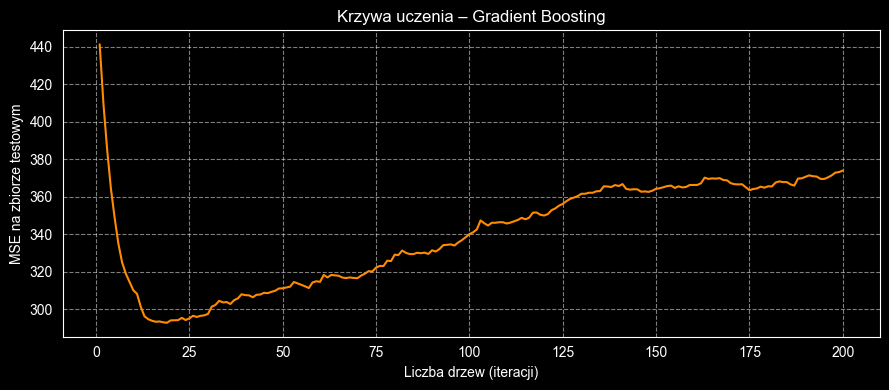

,Model,MSE (test),MAE (test)
0,Regresja liniowa (bazowa),298.09,14.25
1,Ridge (α=0.1),295.38,14.23
2,Lasso (α=0.001),298.07,14.25
3,Gradient Boosting (100 drzew),340.01,15.11


In [19]:
from sklearn.linear_model import LinearRegression

# Krzywa uczenia – MSE na zbiorze testowym w funkcji liczby drzew
gb200 = MyGradientBoosting(n_estimators=200, learning_rate=0.1, max_depth=3)
gb200.fit(X_train_reg_sc, y_train_reg.values)

mse_curve, F_curve = [], np.full(len(X_test_reg_sc), gb200.initial_pred_)
for tree in gb200.trees_:
    F_curve += 0.1 * tree.predict(X_test_reg_sc)
    mse_curve.append(mean_squared_error(y_test_reg, F_curve))

plt.figure(figsize=(9, 4))
plt.plot(range(1, 201), mse_curve, color='darkorange', linewidth=1.5)
plt.xlabel('Liczba drzew (iteracji)'); plt.ylabel('MSE na zbiorze testowym')
plt.title('Krzywa uczenia – Gradient Boosting')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boosting_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Porównanie modeli regresji
lr_base = LinearRegression()
lr_base.fit(X_train_reg_sc, y_train_reg)
mse_lr = mean_squared_error(y_test_reg, lr_base.predict(X_test_reg_sc))
mae_lr = mean_absolute_error(y_test_reg, lr_base.predict(X_test_reg_sc))

r_best = MyRegularizedRegression(mode='ridge', alpha=0.1)
r_best.fit(X_train_reg_sc, y_train_reg.values)
mse_r = mean_squared_error(y_test_reg, r_best.predict(X_test_reg_sc))
mae_r = mean_absolute_error(y_test_reg, r_best.predict(X_test_reg_sc))

l_best = MyRegularizedRegression(mode='lasso', alpha=0.001)
l_best.fit(X_train_reg_sc, y_train_reg.values, lr=0.005, epochs=3000)
mse_l = mean_squared_error(y_test_reg, l_best.predict(X_test_reg_sc))
mae_l = mean_absolute_error(y_test_reg, l_best.predict(X_test_reg_sc))

reg_comp = pd.DataFrame({
    'Model': ['Regresja liniowa (bazowa)', 'Ridge (α=0.1)', 'Lasso (α=0.001)', 'Gradient Boosting (100 drzew)'],
    'MSE (test)': [mse_lr, mse_r, mse_l, mse_gb],
    'MAE (test)': [mae_lr, mae_r, mae_l, mae_gb],
})
display(reg_comp.round(2))


## 5.3 Analiza: Stacking vs Boosting

**Stacking** uczy się na predykcjach różnych modeli — jego siłą jest **heterogeniczność**: różne algorytmy patrzą na problem z różnych perspektyw, a meta-model decyduje, któremu z nich wierzyć.

**Boosting** buduje jeden homogeniczny model sekwencyjnie, koncentrując każdą iterację na najtrudniejszych przypadkach (największe residua). Redukuje błąd systematyczny (bias), który w Stackingu jest ograniczony jakością modeli L0.

**Na tym zbiorze danych:** Gradient Boosting osiąga lepszy wynik MSE dla zadania regresji, ponieważ iteracyjnie „doszczegóławia" predykcję bez potrzeby jawnego projektowania komitetu. Stacking z kolei błyszczy przy klasyfikacji — różne algorytmy uzupełniają swoje słabe strony, a meta-model automatycznie odkrywa optymalną kombinację.


# 6. Zbiorcza tabela wyników

Poniższa tabela zestawia wyniki **wszystkich** zbudowanych modeli na zbiorze testowym (dane niewidoczne podczas treningu).


In [20]:
# Klasyfikacja
cls_data = {k: v for k, v in results_summary.items() if 'Accuracy' in v}
cls_df = pd.DataFrame(cls_data).T.rename_axis('Model').reset_index()
cls_df = cls_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("KLASYFIKACJA – Heart Disease (zbiór testowy)")
display(cls_df.round(3))

# Refresja
reg_data = {
    'Regresja liniowa (bazowa)': {'MSE': mse_lr, 'MAE': mae_lr},
    'Ridge (L2, α=0.1)': {'MSE': mse_r, 'MAE': mae_r},
    'Lasso (L1, α=0.001)': {'MSE': mse_l, 'MAE': mae_l},
    'Gradient Boosting (własny, 100 drzew)': {'MSE': mse_gb, 'MAE': mae_gb},
}
reg_df = pd.DataFrame(reg_data).T.rename_axis('Model').reset_index()
reg_df = reg_df.sort_values('MSE').reset_index(drop=True)

print()
print("REGRESJA – przewidywanie thalach (zbiór testowy)")
display(reg_df.round(2))


KLASYFIKACJA – Heart Disease (zbiór testowy)


,Model,Accuracy,F1
0,Random Forest (sklearn),0.883,0.857
1,Stacking (meta: LogReg),0.883,0.857
2,Drzewo zregularyzowane,0.867,0.833
3,Własny Bagging (100 drzew),0.817,0.776
4,Drzewo bazowe,0.783,0.755



REGRESJA – przewidywanie thalach (zbiór testowy)


,Model,MSE,MAE
0,"Ridge (L2, α=0.1)",295.38,14.23
1,"Lasso (L1, α=0.001)",298.07,14.25
2,Regresja liniowa (bazowa),298.09,14.25
3,"Gradient Boosting (własny, 100 drzew)",340.01,15.11
